<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/nlp/07-BiLSTM/Project_02_BidirectionalLSTM_MNIST_TFllow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Bidirectional, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import  Adam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split

# Load in the data

In [ ]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), _ = mnist.load_data()
print("x_train.shape:", x_train.shape)

# Extract first 10000 samples

In [ ]:
X  = x_train[0:10000, :]

In [ ]:
X.shape # N x T x D

In [5]:
y = y_train[0:10000]

In [6]:
y.shape

(10000,)

# Perform Train test split

In [7]:
train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size = 0.1)

In [8]:
train_data[0].shape  # shape of the first sample of train_data

(28, 28)

# Create the Model

In [9]:
i = Input(train_data[0].shape) # T x D. Here  T x D = 28 x 28
Bi_LSTM = Bidirectional(LSTM(128, return_sequences = True))
X = Bi_LSTM(i)
X = GlobalMaxPooling1D()(X)
X = Dense(10, activation='softmax')(X)
model = Model(i, X)

In [ ]:
# i = Input(train_data[0].shape) # T x D. Here  T x D = 28 x 28
# x = LSTM(128)(i)
# x = Dense(10, activation='softmax')(x)
# model = Model(i, x)

# Compile the Model

In [10]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the Model

In [11]:
hist = model.fit(train_data, train_labels, validation_data=(test_data, test_labels), epochs = 50)

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step - accuracy: 0.7026 - loss: 1.0548 - val_accuracy: 0.8560 - val_loss: 0.5342
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.8834 - loss: 0.4062 - val_accuracy: 0.8810 - val_loss: 0.3670
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.9152 - loss: 0.2878 - val_accuracy: 0.9070 - val_loss: 0.3001
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.9321 - loss: 0.2313 - val_accuracy: 0.9220 - val_loss: 0.2690
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9373 - loss: 0.2067 - val_accuracy: 0.9120 - val_loss: 0.2738
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9449 - loss: 0.1836 - val_accuracy: 0.9330 - val_loss: 0.2358
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 36s 67ms/step - accuracy: 0.9549 - loss: 0.1527 - val_accuracy: 0.9170 - val_loss: 0.2364
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.9572 - loss: 0.1416 - 

# Visualize the Model Performance

In [12]:
trainAcc = [100 * x for x in hist.history['accuracy']]
testAcc = [100 * x for x in hist.history['val_accuracy']]

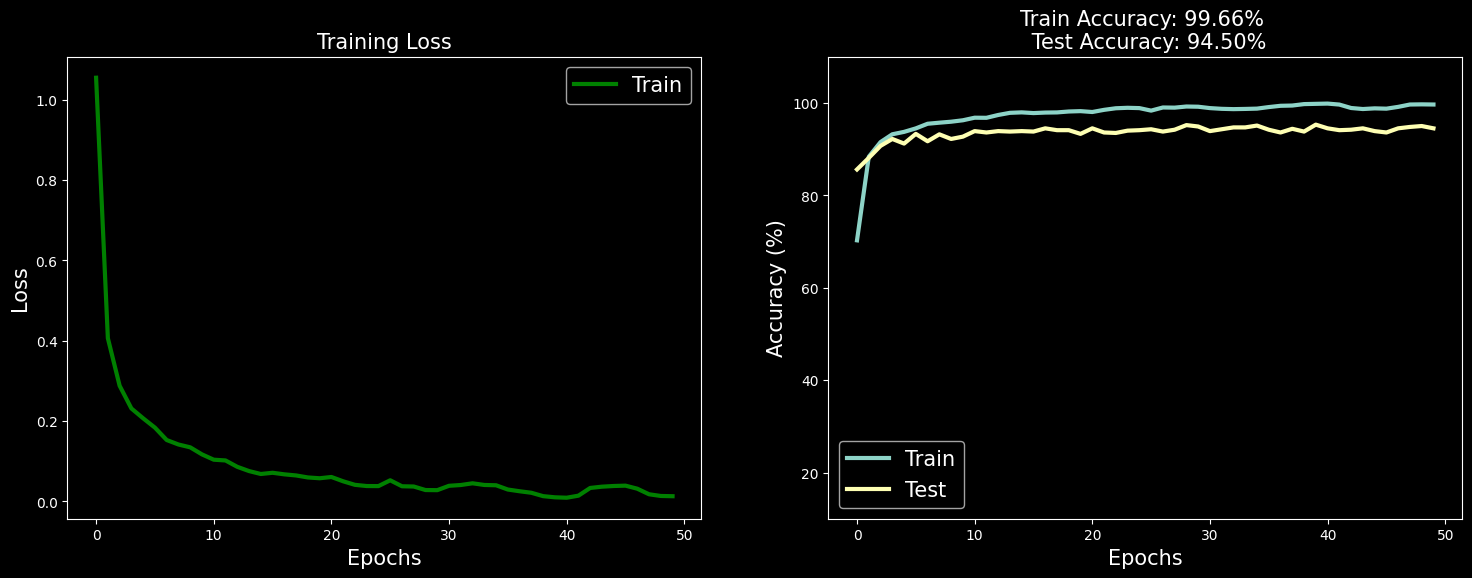

In [13]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

ax[0].plot(hist.history['loss'], 'g', lw = 3, label = 'Train')
ax[0].set_xlabel('Epochs', fontsize = 15)
ax[0].set_ylabel('Loss', fontsize = 15)
ax[0].legend(fontsize = 15)
ax[0].set_title('Training Loss', fontsize = 15)


ax[1].plot(trainAcc, label ='Train', lw = 3)
ax[1].plot(testAcc, label ='Test', lw = 3)
ax[1].set_xlabel('Epochs', fontsize = 15)
ax[1].set_ylabel('Accuracy (%)', fontsize = 15)
ax[1].set_ylim([10,110])
ax[1].set_title(f'Train Accuracy: {trainAcc[-1]:.2f}% \n Test Accuracy: {testAcc[-1]:.2f}%', fontsize = 15)
ax[1].legend(fontsize = 15)

plt.show()